In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

print("loading dataset...")

labeled_dataset = pd.read_csv('data/labeled_processed.csv')
#labeled_dataset = pd.read_csv('data/labeled_processed_simplified.csv')

print("dataset loaded!")

train, temp = train_test_split(
    labeled_dataset,
    test_size=0.3,
    random_state=1,
    stratify=labeled_dataset['event_type']
)
val, test = train_test_split(
    temp,
    test_size=0.5,
    random_state=1,
    stratify=temp['event_type']
)

fields_to_drop = [
    'sample', 'file_name', 'ML_1', 'ML_1_1', 'ML_1_1_1', 'ML_1_2','ML_2','ML_2_1_1','ML_2_1_2','ML_2_1_3','ML_2_2','ML_2_3',
    'ML_2_3_1','ML_2_4_1','ML_2_4_2','ML_2_5_1','ML_2_6','ML_2_7_1','ML_2_7_2','ML_3','ML_3_1','ML_3_2','ML_3_3','ML_3_4',
    'ML_3_5', 'event_type']

train_features = train.drop(fields_to_drop, axis=1)
train_labels = train['event_type']

val_features = val.drop(fields_to_drop, axis=1)
val_labels = val['event_type']

test_features = test.drop(fields_to_drop, axis=1)
test_labels = test['event_type']


loading dataset...
dataset loaded!


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 1.9047885	test: 1.9053021	best: 1.9053021 (0)	total: 1.77s	remaining: 2m 55s
1:	learn: 1.6417121	test: 1.6432574	best: 1.6432574 (1)	total: 3.54s	remaining: 2m 53s
2:	learn: 1.4732847	test: 1.4751196	best: 1.4751196 (2)	total: 5.2s	remaining: 2m 48s
3:	learn: 1.3481693	test: 1.3501106	best: 1.3501106 (3)	total: 6.84s	remaining: 2m 44s
4:	learn: 1.2298662	test: 1.2315921	best: 1.2315921 (4)	total: 8.49s	remaining: 2m 41s
5:	learn: 1.1408615	test: 1.1426954	best: 1.1426954 (5)	total: 10.2s	remaining: 2m 39s
6:	learn: 1.0635611	test: 1.0654179	best: 1.0654179 (6)	total: 11.8s	remaining: 2m 37s
7:	learn: 0.9913118	test: 0.9930233	best: 0.9930233 (7)	total: 13.6s	remaining: 2m 36s
8:	learn: 0.9374867	test: 0.9391342	best: 0.9391342 (8)	total: 15.4s	remaining: 2m 35s
9:	learn: 0.8891442	test: 0.8907943	best: 0.8907943 (9)	total: 17.1s	remaining: 2m 33s
10:	learn: 0.8472255	test: 0.8487785	best: 0.8487785 (10)	total: 18.7s	remaining: 2m 31s
11:	learn: 0.8138872	test: 0.8155176	best:

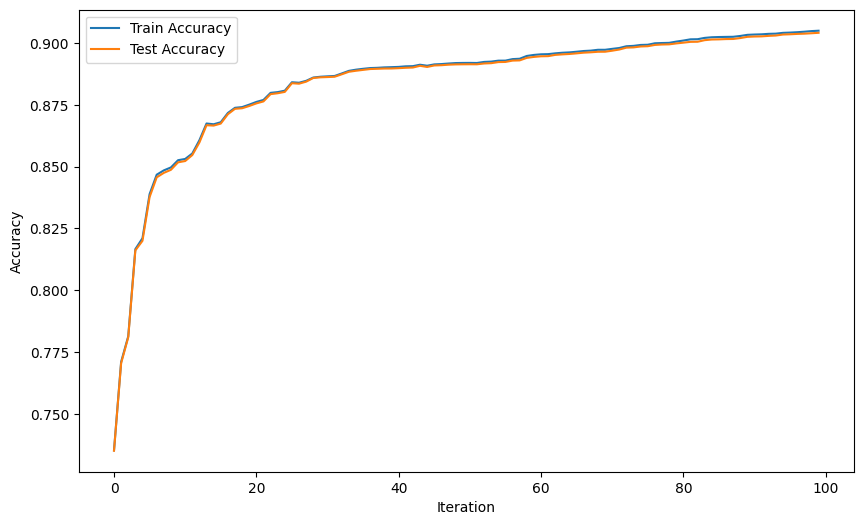

Best Train Accuracy: 0.9049143449481867
Best Test Accuracy: 0.9040691470441773


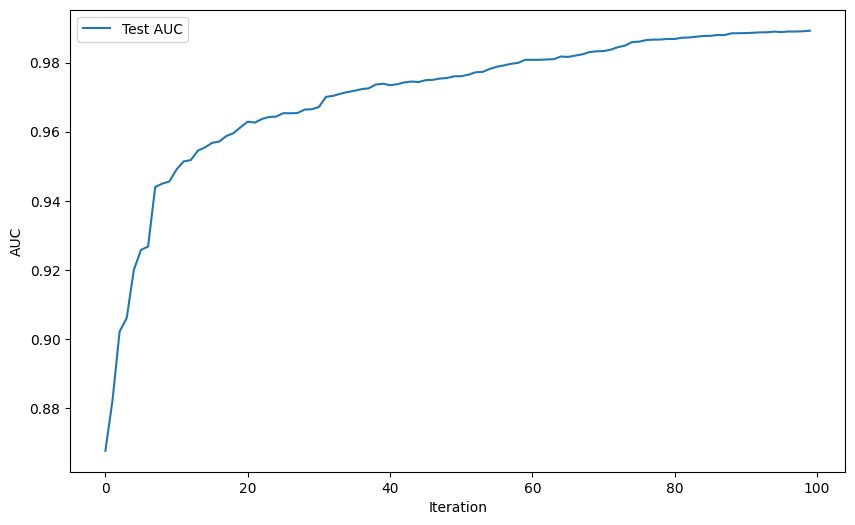

Best Val AUC: 0.9891944419718998
Test accuracy: 0.3947733474255459


In [6]:
classifier = CatBoostClassifier(
    iterations=100,
    random_seed=2,
    learning_rate=0.1,
    custom_loss=['AUC', 'Accuracy']
)

classifier.fit(
    train_features, train_labels,
    eval_set=(val_features, val_labels),
    verbose=1,
    plot=True
)

plt.figure(figsize=(10, 6))
plt.plot(classifier.evals_result_['learn']['Accuracy'], label='Val Accuracy')
plt.plot(classifier.evals_result_['validation']['Accuracy'], label='Val Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
print(f"Best Train Accuracy: {classifier.evals_result_['learn']['Accuracy'][-1]}")
print(f"Best Test Accuracy: {classifier.evals_result_['validation']['Accuracy'][-1]}")

plt.figure(figsize=(10, 6))
plt.plot(classifier.evals_result_['validation']['AUC:type=Mu'], label='Val AUC')
plt.xlabel('Iteration')
plt.ylabel('AUC')
plt.legend()
plt.show()

print(f"Best Val AUC: {classifier.evals_result_['validation']['AUC:type=Mu'][-1]}")
test_score = classifier.score(test_features, test_labels)
print(f"Test accuracy: {test_score}")

In [6]:
#classifier.save_model("trained_osc_grid_catboost", format="cbm")

# Observations